# EDS 232 Machine Learning Kaggle Competition

## Background

**This notebook tests several machine learning models to find the one that best predicts dissolved inorganic carbon (DIC) concentration (umol/kg) in seawater samples collected off the California coast.**

**The data come from the California Cooperative Oceanic Fisheries Investigations (CalCOFI), one of the longest-running ocean monitoring programs in the world. Each row corresponds to a single water sample, described by total alkalinity (TA) (umol/kg), seawater practical salinity (ppt(PSS78)), seawater temperature (°C), depth (m), and dissolved inorganic carbon (DIC) (umol/kg).**

## Setup

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV

## Exploratory Data Analysis 

In [2]:
# Read in data 
train_data = pd.read_csv('data/train.csv')

test_data = pd.read_csv('data/test.csv')

# Extract feature names 
feature_names = ['CTDTEMP_ITS90', 'Salinity_PSS78', 'Depth', 'TA']


In [3]:
# Extract training response 
y_train = train_data.DIC

# Extract training predictors

X_train = train_data.set_index('id')[feature_names]

# Extract testing predictors
X_test = test_data.set_index('id')[feature_names]

In [4]:
# Ensure NA are not present in data 
# Return rows with NA
print(X_train[X_train.isna().any(axis=1)])

print(X_test[X_test.isna().any(axis=1)])

print(y_train[y_train.isna()])

Empty DataFrame
Columns: [CTDTEMP_ITS90, Salinity_PSS78, Depth, TA]
Index: []
Empty DataFrame
Columns: [CTDTEMP_ITS90, Salinity_PSS78, Depth, TA]
Index: []
Series([], Name: DIC, dtype: float64)


In [5]:
# Print shape of all test and training splits 
print(f"The training predictors contain {X_train.shape[0]} rows and {X_train.shape[1]} columns")
print(f"The training response contains {y_train.shape[0]} rows")
print(f"The testing predictors contain {X_test.shape[0]} rows and {X_test.shape[1]} columns")

The training predictors contain 3389 rows and 4 columns
The training response contains 3389 rows
The testing predictors contain 848 rows and 4 columns


In [6]:
X_train

,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA
id,,,,
0,15.360,33.6095,10.0,2241.0
1,11.230,33.6095,10.0,2241.0
2,11.230,33.6095,10.0,2241.0
3,11.230,33.6095,10.0,2241.0
4,15.060,33.2820,10.0,2241.0
...,...,...,...,...
4231,9.222,34.2520,270.0,2281.0
4232,10.151,33.8650,100.0,2241.5
4233,14.179,33.4060,27.0,2228.7


In [7]:
X_test

,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA
id,,,,
6,15.230,33.3950,10.0,2241.0
8,11.230,33.2320,10.0,2241.0
12,19.330,33.4550,10.0,2241.0
14,20.960,33.4670,10.0,2241.0
17,11.230,33.6095,10.0,2241.0
...,...,...,...,...
4215,11.230,33.6095,1.0,2237.1
4222,16.579,33.5330,30.0,2237.8
4226,17.538,33.2300,31.0,2220.8


In [8]:
y_train

0       1989.4
1       1989.8
2       1989.3
3       1988.6
4       1991.5
         ...  
3384    2245.8
3385    2151.0
3386    2026.0
3387    1996.9
3388    2011.5
Name: DIC, Length: 3389, dtype: float64

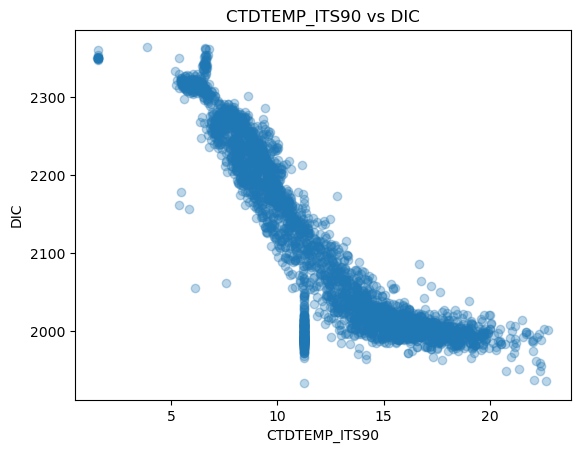

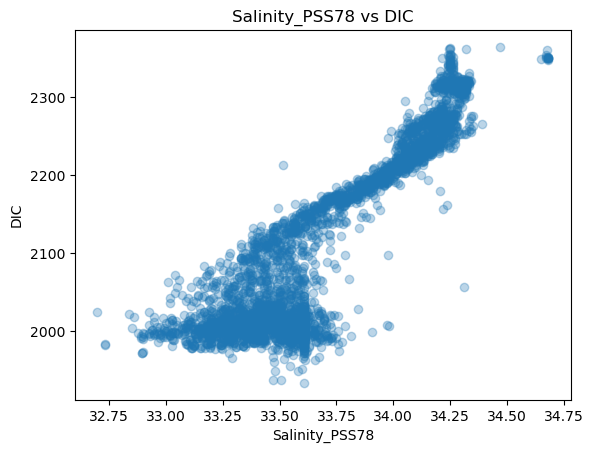

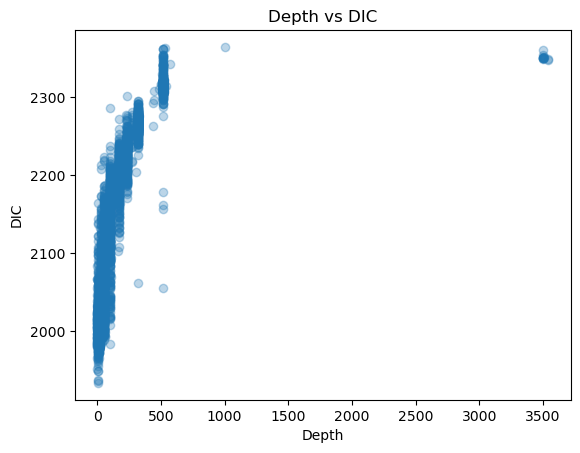

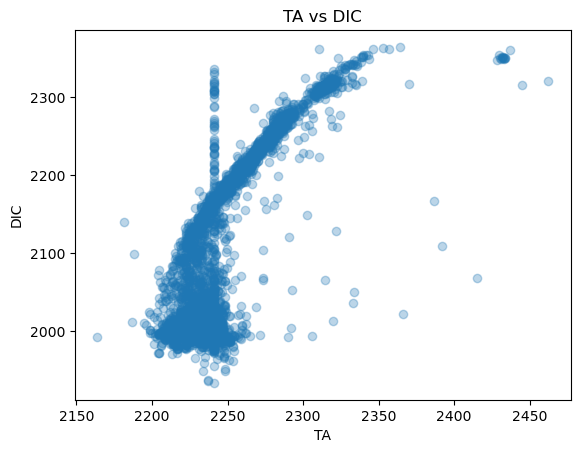

In [20]:
for feat in feature_names:
    plt.scatter(train_data[feat], train_data['DIC'], alpha=0.3)
    plt.xlabel(feat)
    plt.ylabel('DIC')
    plt.title(f'{feat} vs DIC')
    plt.show()

## Models 

In [9]:
# Fit the scaler ONLY on train data and transform only on X
scaler = StandardScaler().fit(X_train)

# Maintain columns 
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [10]:
# Create lambdas list 
lambdas = np.logspace(-4,4, 100)

### Predict using Ridge Model

In [11]:
# Create and fit Ridge regression model
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_s, y_train)
ridge_cv.alpha_

31.257158496882415

In [12]:
# Predict y values using x test
y_test_pred_rcv = ridge_cv.predict(X_test_s)

y_test_pred_rcv = pd.Series(y_test_pred_rcv, index=X_test.index)

### Predict using Lasso Model

In [13]:
# Create and fit Lasso regression model
lasso_cv = LassoCV(alphas=lambdas, cv=10)
lasso_cv.fit(X_train_s, y_train)
lasso_cv.alpha_

1.9179102616724888

In [14]:
# Predict y values using x test for Lasso
y_test_pred_lcv = lasso_cv.predict(X_test_s)

y_test_pred_lcv = pd.Series(y_test_pred_lcv, index=X_test.index)

In [15]:
# Create data frames for Ridge and Lasso 
submission_ridge = pd.DataFrame({"id": X_test.index, "DIC": y_test_pred_rcv})

submission_ridge.to_csv("submission_ridge.csv", index=False)

submission_lasso = pd.DataFrame({"id": X_test.index, "DIC": y_test_pred_lcv})

submission_lasso.to_csv("submission_lasso.csv", index=False)

In [16]:
# Store coefficients associated with each lambda fitting
coefs_ridge = []

for lam in lambdas:
    ridge = Ridge(alpha=lam) #Get a model for each lambda value 
    ridge.fit(X_train_s, y_train) # fit to trained data 
    coefs_ridge.append(ridge.coef_)

coefs_ridge = np.array(coefs_ridge)

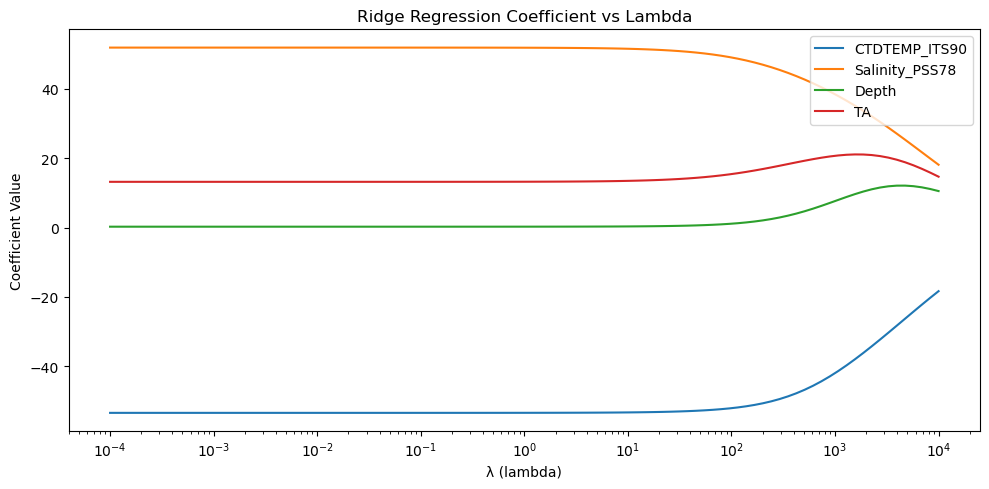

In [17]:
# Visualize lambdas for each coefficient 
plt.figure(figsize=(10, 5))

for i in range(len(feature_names)): # Feature names are in the same order as resulting coefficient table (coef)
    plt.plot(lambdas, coefs_ridge[:, i], label=feature_names[i]) # Plot feature name and associated lambda 

plt.xscale('log')
plt.xlabel('λ (lambda)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression Coefficient vs Lambda')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Store coefficients associated with each lambda fitting
coefs_lasso = []

for lam in lambdas:
    lasso = Lasso(alpha=lam)
    lasso.fit(X_train_s, y_train)
    coefs_lasso.append(lasso.coef_)

coefs_lasso = np.array(coefs_lasso)

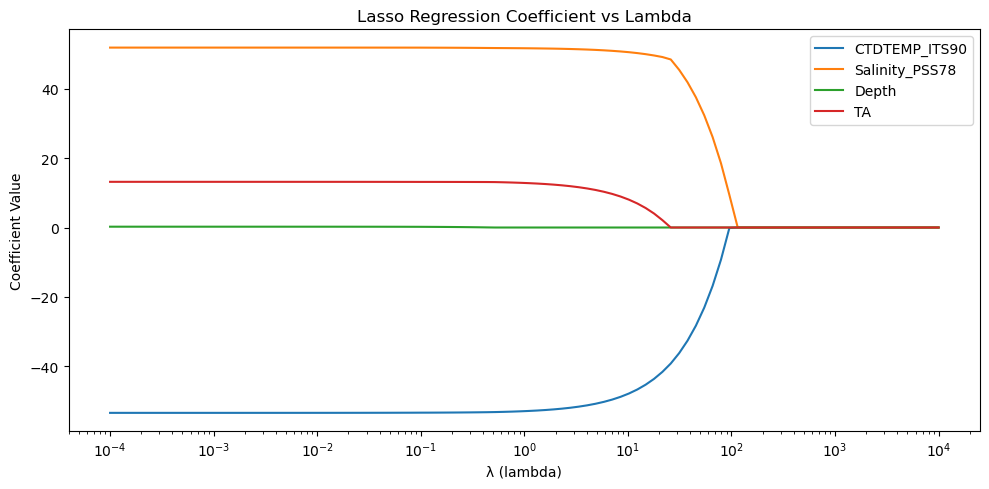

In [19]:
plt.figure(figsize=(10, 5))

for i in range(len(feature_names)):
    plt.plot(lambdas, coefs_lasso[:, i], label=feature_names[i])

plt.xscale('log')
plt.xlabel('λ (lambda)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression Coefficient vs Lambda')
plt.legend()
plt.tight_layout()
plt.show()

<Axes: >

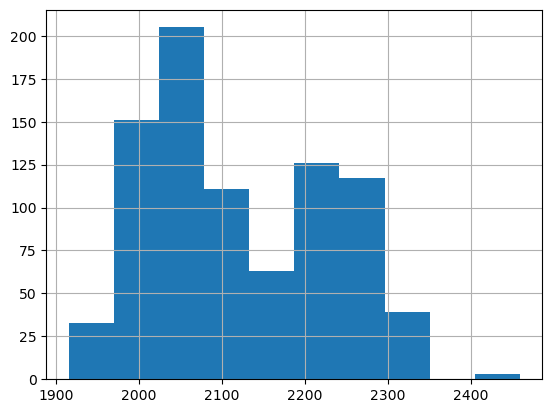

In [22]:
y_test_pred_lcv.hist()

<Axes: >

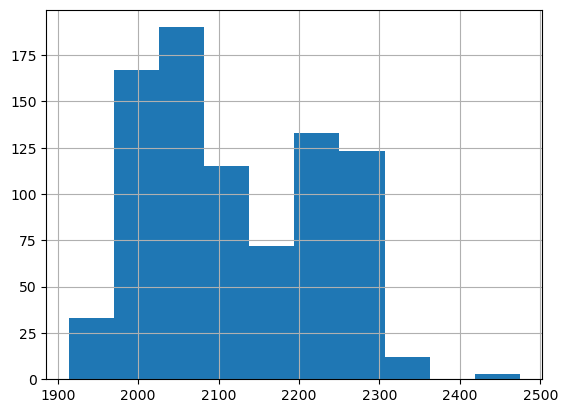

In [23]:
y_test_pred_rcv.hist()